# Практическая работа №4. Работа с векторными данными в GeoPandas

Выполняя практическую работу, опирайтесь на теоритический материал, рассматриваемый на занятии:

*   Использование NumPy, Pandas и GeoPandas для работы с пространственными данными: https://u.to/rk86Ig
*   Ультимативный обзор аналитических инструментов GeoPandas: https://u.to/s0d3Ig
*   Теоретические аспекты и практические примеры получения векторных данных из OpenStreetMap: https://u.to/9SdwIQ

Дополнительно:

*   Особенности построения интерактивных карт с помощью библиотеки Leafmap: https://u.to/WvA3Ig
*   Официальная техническая документацию по используемым библиотекам:
    *   NumPy: https://numpy.org/doc/stable/
    *   Pandas: https://pandas.pydata.org/docs/
    *   GeoPandas: https://geopandas.org/en/stable/docs.html
    *   Leafmap: https://leafmap.org/

### Задание №1. Операции с массивами NumPy и геопространственными координатами
Создайте двумерный массив NumPy, содержащий широту и долготу следующих городов: Токио (35.6895, 139.6917), Нью-Йорк (40.7128, -74.0060), Лондон (51.5074, -0.1278) и Париж (48.8566, 2.3522).

In [1]:
import numpy as np

# Создаем двумерный массив: строки - города, столбцы - [широта, долгота]
coords = np.array([
    [35.6895, 139.6917],  # Токио
    [40.7128, -74.0060],  # Нью-Йорк
    [51.5074, -0.1278],   # Лондон
    [48.8566, 2.3522]     # Париж
])
print("Координаты городов (градусы):\n", coords)

Координаты городов (градусы):
 [[ 3.568950e+01  1.396917e+02]
 [ 4.071280e+01 -7.400600e+01]
 [ 5.150740e+01 -1.278000e-01]
 [ 4.885660e+01  2.352200e+00]]


Преобразуйте значения широты и долготы из градусов в радианы с помощью функции np.radians().

In [2]:
# Преобразуем градусы в радианы
coords_rad = np.radians(coords)
print("Координаты городов (радианы):\n", coords_rad)

Координаты городов (радианы):
 [[ 6.22899283e-01  2.43808010e+00]
 [ 7.10572408e-01 -1.29164837e+00]
 [ 8.98973719e-01 -2.23053078e-03]
 [ 8.52708531e-01  4.10536347e-02]]


Рассчитайте поэлементную разницу между координатами Токио и других городов в радианах.

In [3]:
# Токио находится под индексом 0
tokyo_rad = coords_rad[0]
# Остальные города - индексы от 1 и до конца
other_cities_rad = coords_rad[1:]

# Рассчитываем поэлементную разницу (векторная операция)
diff_rad = tokyo_rad - other_cities_rad
print("Поэлементная разница (Токио минус Нью-Йорк, Лондон, Париж):\n", diff_rad)

Поэлементная разница (Токио минус Нью-Йорк, Лондон, Париж):
 [[-0.08767312  3.72972847]
 [-0.27607444  2.44031063]
 [-0.22980925  2.39702647]]


### Задание 2. Операции с DataFrame Pandas и геопространственными данными
Загрузите набор данных о городах мира по следующему URL с помощью Pandas: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv

In [4]:
import pandas as pd

url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"
df = pd.read_csv(url)
print("Датасет успешно загружен!")

Датасет успешно загружен!


Отобразите первые 5 строк и проверьте наличие отсутствующих значений.

In [5]:
display(df.head())

print("\nПроверка отсутствующих значений по столбцам:")
print(df.isnull().sum())

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.5833,32.5333,75000
1,2,Fort Portal,UGA,0.6710,30.2750,42670
2,3,Potenza,ITA,40.6420,15.7990,69060
3,4,Campobasso,ITA,41.5630,14.6560,50762
4,5,Aosta,ITA,45.7370,7.3150,34062



Проверка отсутствующих значений по столбцам:
id            0
name          0
country       0
latitude      0
longitude     0
population    0
dtype: int64


Отфильтруйте набор данных, чтобы включить только города с населением более 1 миллиона человек.

In [6]:
# Находим правильное название колонки с населением (обычно 'pop_max')
pop_col = 'pop_max' if 'pop_max' in df.columns else 'population'

df_1m = df[df[pop_col] > 1000000].copy()
print(f"Городов с населением > 1 млн: {len(df_1m)}")

Городов с населением > 1 млн: 392


Сгруппируйте города по странам и рассчитайте общую численность населения для каждой страны.

In [7]:
# Группируем по стране и суммируем население
country_col = 'country' if 'country' in df.columns else 'adm0name'

pop_by_country = df.groupby(country_col)[pop_col].sum().reset_index()
pop_by_country.rename(columns={pop_col: 'total_population'}, inplace=True)

display(pop_by_country.head())

,country,total_population
0,AFG,4931702
1,AGO,6821544
2,ALB,895350
3,ALD,10682
4,AND,53998


Отсортируйте города по населению в порядке убывания и отобразите первые 10 городов.

In [8]:
top_10_cities = df.sort_values(by=pop_col, ascending=False).head(10)
display(top_10_cities[['name', country_col, pop_col]])

,name,country,population
1239,Tokyo,JPN,35676000
1224,New York,USA,19040000
1230,Mexico City,MEX,19028000
1240,Mumbai,IND,18978000
1245,Sao Paulo,BRA,18845000
1148,Delhi,IND,15926000
1238,Shanghai,CHN,14987000
1243,Kolkata,IND,14787000
1175,Dhaka,BGD,12797394
1217,Buenos Aires,ARG,12795000


### Задание №3. Создание и обработка GeoDataFrames с помощью GeoPandas
Загрузите набор данных о зданиях Нью-Йорка из файла GeoJSON с помощью GeoPandas: https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt

url_nyc = "https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson"
gdf_nyc = gpd.read_file(url_nyc)
print("Данные о зданиях Нью-Йорка загружены!")

Данные о зданиях Нью-Йорка загружены!


Создайте график контуров зданий и раскрасьте их в зависимости от высоты здания (используйте столбец height_MS).

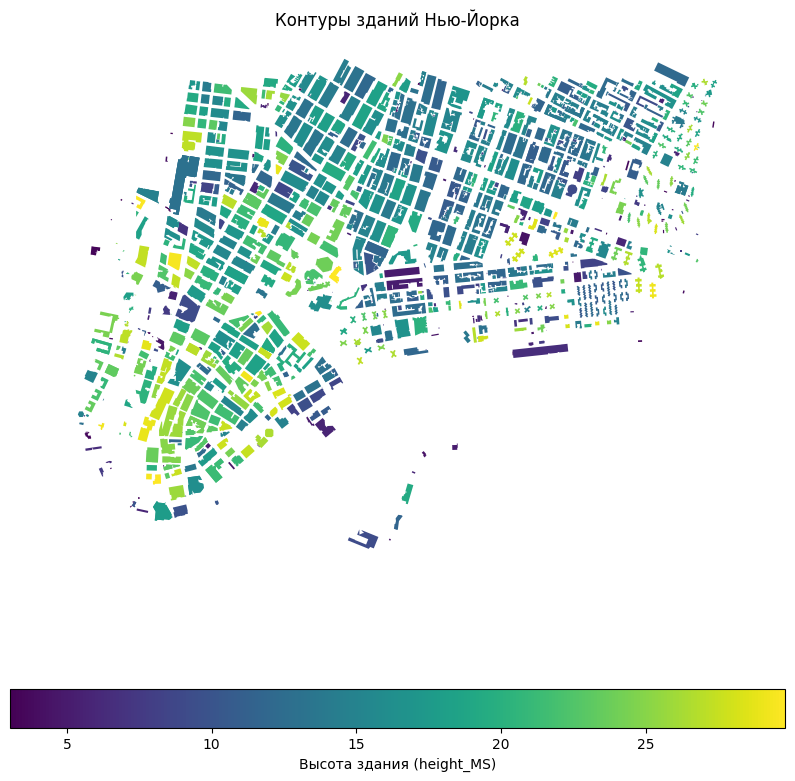

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf_nyc.plot(column='height_MS', cmap='viridis', legend=True, ax=ax, 
             legend_kwds={'label': "Высота здания (height_MS)", 'orientation': "horizontal"})
plt.title("Контуры зданий Нью-Йорка")
plt.axis('off')
plt.show()

Создайте интерактивную карту контуров зданий и раскрасьте их в зависимости от высоты здания (используйте столбец height_MS).

In [11]:
import leafmap

# Создаем интерактивную карту
m1 = leafmap.Map(center=[40.71, -74.00], zoom=14)

# Добавляем здания
m1.add_data(gdf_nyc, column='height_MS', cmap='viridis', scheme='Quantiles', k=5, add_legend=True)
m1

Map(center=[40.71, -74.0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

Рассчитайте среднюю высоту зданий (используйте столбец height_MS).

In [12]:
mean_height = gdf_nyc['height_MS'].mean()
print(f"Средняя высота зданий: {mean_height:.2f}")

Средняя высота зданий: 15.45


Выберите здания с высотой, превышающей среднюю высоту.

In [13]:
gdf_tall = gdf_nyc[gdf_nyc['height_MS'] > mean_height].copy()
print(f"Количество зданий выше среднего: {len(gdf_tall)}")

Количество зданий выше среднего: 524


Сохраните GeoDataFrame в новый файл GeoJSON.

In [14]:
output_filename = "nyc_tall_buildings.geojson"
gdf_tall.to_file(output_filename, driver="GeoJSON")
print(f"Файл успешно сохранен как {output_filename}")

Файл успешно сохранен как nyc_tall_buildings.geojson


### Задание №4. Применение NumPy, Pandas и GeoPandas для обработки и анализа пространственных данных
Используйте Pandas для загрузки набора данных о городах мира по следующему URL: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv

In [15]:
df2 = pd.read_csv("https://github.com/opengeos/datasets/releases/download/world/world_cities.csv")
print("Повторная загрузка выполнена.")

Повторная загрузка выполнена.


Отфильтруйте набор данных, чтобы включить только города с широтой между -40 и 60 (т.е. города, расположенные в Северном полушарии или вблизи экватора).

In [16]:
lat_col = 'latitude'
lon_col = 'longitude'

df2_filtered = df2[(df2[lat_col] >= -40) & (df2[lat_col] <= 60)].copy()
print(f"Городов после фильтрации: {len(df2_filtered)}")

Городов после фильтрации: 1132


Создайте GeoDataFrame из отфильтрованного набора данных, преобразовав широту и долготу в геометрии.

In [17]:
# Преобразуем координаты в точки (Point)
geometry = gpd.points_from_xy(df2_filtered[lon_col], df2_filtered[lat_col])

# Задаем стандартную систему координат WGS84 (EPSG:4326)
gdf2 = gpd.GeoDataFrame(df2_filtered, geometry=geometry, crs="EPSG:4326")
display(gdf2.head())

,id,name,country,latitude,longitude,population,geometry
0,1,Bombo,UGA,0.5833,32.5333,75000,POINT (32.5333 0.5833)
1,2,Fort Portal,UGA,0.6710,30.2750,42670,POINT (30.275 0.671)
2,3,Potenza,ITA,40.6420,15.7990,69060,POINT (15.799 40.642)
3,4,Campobasso,ITA,41.5630,14.6560,50762,POINT (14.656 41.563)
4,5,Aosta,ITA,45.7370,7.3150,34062,POINT (7.315 45.737)


Перепроецируйте GeoDataFrame в проекцию Меркатора (EPSG:3857).

In [18]:
# Перепроецируем для точного расчета расстояний в метрах
gdf2_3857 = gdf2.to_crs("EPSG:3857")
print("Новая проекция:", gdf2_3857.crs)

Новая проекция: EPSG:3857


Рассчитайте расстояние (в метрах) между каждым городом и Парижем.

In [19]:
from shapely.geometry import Point

# Координаты Парижа (долгота, широта)
paris_point = Point(2.3522, 48.8566)

# Создаем GeoSeries с одной точкой, задаем CRS 4326 и переводим в 3857 (Меркатор)
paris_geom = gpd.GeoSeries([paris_point], crs="EPSG:4326").to_crs("EPSG:3857").iloc[0]

# Рассчитываем расстояние в метрах
gdf2_3857['dist_to_paris_m'] = gdf2_3857.geometry.distance(paris_geom)

# Переводим в километры, как просят в подсказке для следующего шага
gdf2_3857['dist_to_paris_km'] = gdf2_3857['dist_to_paris_m'] / 1000.0

display(gdf2_3857[['name', 'dist_to_paris_km']].head())

,name,dist_to_paris_km
0,Bombo,7039.169686
1,Fort Portal,6913.984947
2,Potenza,1976.630133
3,Campobasso,1791.525362
4,Aosta,753.405430


Отобразите города на карте мира, раскрасив точки в зависимости от их расстояния до Парижа.

💡 Подсказка: Вы можете использовать интерактивную карту leafmap.Map() и метод m.add_data(), передав в него ваш GeoDataFrame (предварительно возвращенный в систему координат EPSG:4326).

Основные параметры данного метода:
* column — столбец с рассчитанным расстоянием до Парижа (предварительно разделите значение расстояния на 1000, чтобы легенда отображалась в километрах).
* cmap — цветовая палитра (например, "plasma", "viridis" или "YlOrRd").
* k — количество цветовых интервалов (рекомендуется 10–15 для плавности).
* scheme — алгоритм классификации данных:
  * "Quantiles" (Квантили) — делит города на группы с равным количеством точек в каждой. Это создаст максимальный цветовой контраст: даже если города расположены кучно, вы увидите разницу между ними.
  * "EqualInterval" (Равные интервалы) — делит весь диапазон расстояний на равные отрезки в километрах (например, 0-1000 км, 1000-2000 км и т.д.). Это нагляднее показывает реальный масштаб удаленности.
* установите параметр add_legend=True, чтобы на карте появилась шкала соответствия цветов и расстояний.

In [20]:
# Возвращаем датасет в EPSG:4326 для корректного отображения на карте leafmap
gdf_map = gdf2_3857.to_crs("EPSG:4326")

# Создаем и настраиваем интерактивную карту мира
m2 = leafmap.Map(center=[20, 0], zoom=2)

m2.add_data(
    gdf_map, 
    column='dist_to_paris_km', 
    cmap='plasma', 
    k=12, 
    scheme='Quantiles', 
    add_legend=True
)

m2

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…